In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression

In [5]:
# 1. BACA DATA
df = pd.read_csv('dataset\harga_rumah.csv')

# EDA

In [6]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Id         2000 non-null   int64
 1   Area       2000 non-null   int64
 2   Bedrooms   2000 non-null   int64
 3   Bathrooms  2000 non-null   int64
 4   Floors     2000 non-null   int64
 5   YearBuilt  2000 non-null   int64
 6   Location   2000 non-null   str  
 7   Condition  2000 non-null   str  
 8   Garage     2000 non-null   str  
 9   Price      2000 non-null   int64
dtypes: int64(7), str(3)
memory usage: 156.4 KB


In [8]:
df.shape

(2000, 10)

In [9]:
df.isnull().sum()

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


## Insight 

1. Perilaku Harga (Price Behavior):
- Harga rumah menunjukkan sebaran yang luas, mengindikasikan adanya percampuran antara properti dengan anggaran rendah (murah) dan properti mewah.
- Distribusinya menunjukkan tidak ada pencilan (outlier) yang ekstrem, tetapi keberadaan rumah-rumah bernilai tinggi terlihat sangat jelas.

2. Luas Area vs Harga:
- Luas area adalah faktor penentu harga yang paling kuat — rumah yang lebih besar hampir selalu lebih mahal.
- Banyak rumah berukuran sedang mengelompok di kisaran 1.500–3.000 kaki persegi (sq.ft), yang membentuk bagian utama dari dataset ini.

3. Kamar Tidur & Kamar Mandi:
- Memiliki lebih banyak kamar tidur atau kamar mandi umumnya akan meningkatkan harga, tetapi:
- Setelah mencapai 4 kamar tidur, dampak penambahannya terhadap harga menjadi lebih lemah.
- Kamar mandi memiliki pengaruh yang lebih kuat terhadap harga dibandingkan dengan kamar tidur.

4. Kondisi Rumah:
- Rumah yang berlabel Sangat Baik (Excellent) atau Baik (Good) mendominasi sebagian besar data.
- Rumah dengan kondisi Sangat Baik secara konsisten dihargai lebih tinggi, terlepas dari seberapa luas areanya.
- Kondisi Cukup (Fair) atau Buruk (Poor) lebih jarang ditemukan dan biasanya muncul pada rentang harga yang lebih rendah.

5. Wawasan Lokasi:
- Lokasi Pusat Kota (Downtown) dan Perkotaan (Urban) menunjukkan rata-rata harga tertinggi.
- Properti di Pedesaan (Rural) secara signifikan lebih murah meskipun luas areanya besar.
- Rumah di Pinggiran Kota (Suburban) berada pada rentang harga menengah.

6. Tahun Dibangun:
- Terdapat rumah lama maupun rumah baru:
- Rumah yang lebih tua (sebelum tahun 1950) cenderung lebih murah, kecuali jika telah direnovasi (berkondisi Sangat Baik).
- Rumah yang lebih baru (setelah tahun 2000) menunjukkan harga yang lebih tinggi dan lebih stabil.

7. Jumlah Lantai:
- Jumlah lantai hanya memiliki sedikit pengaruh terhadap harga.
- Rumah satu lantai dan dua lantai mendominasi dataset ini.

8. Garasi:
- Rumah yang memiliki garasi rata-rata memiliki harga yang lebih tinggi.
- Kesenjangan harga antara Ada Garasi (Garage = Yes) dan Tidak Ada Garasi (Garage = No) terlihat jelas, namun tidak terlalu ekstrem.

9. Kualitas Data:
- Dataset ini memiliki:
- Tidak ada data yang hilang (missing values).
- Distribusi fitur yang seimbang.
- Tidak ada masalah multikolinearitas yang mengganggu.

## Visualisasi Data

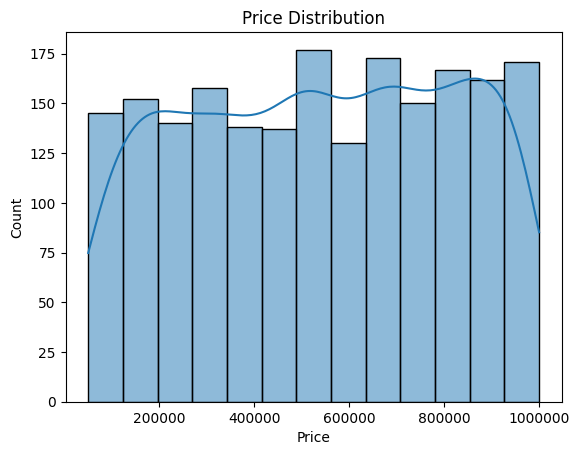

In [12]:
sns.histplot(df['Price'],kde=True)
plt.gca().ticklabel_format(style='plain')
plt.title('Price Distribution')
plt.show()

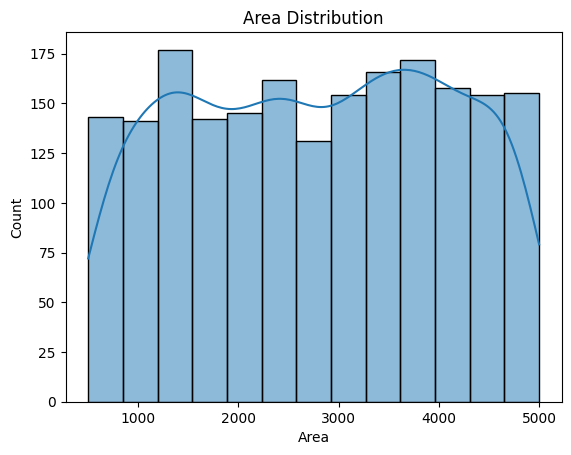

In [13]:
sns.histplot(df['Area'],kde=True)
plt.gca().ticklabel_format(style='plain')
plt.title('Area Distribution')
plt.show()

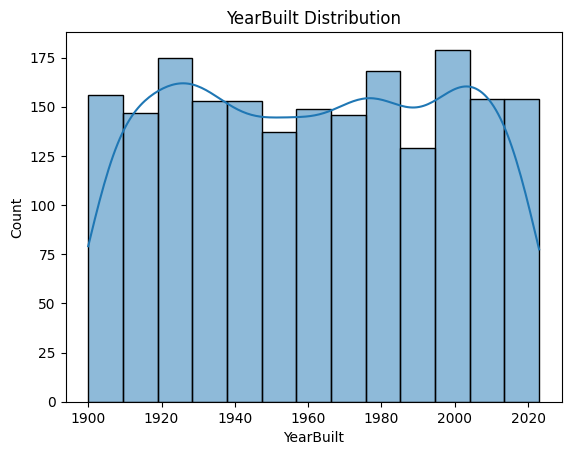

In [14]:
sns.histplot(df['YearBuilt'],kde=True)
plt.title('YearBuilt Distribution')
plt.show()

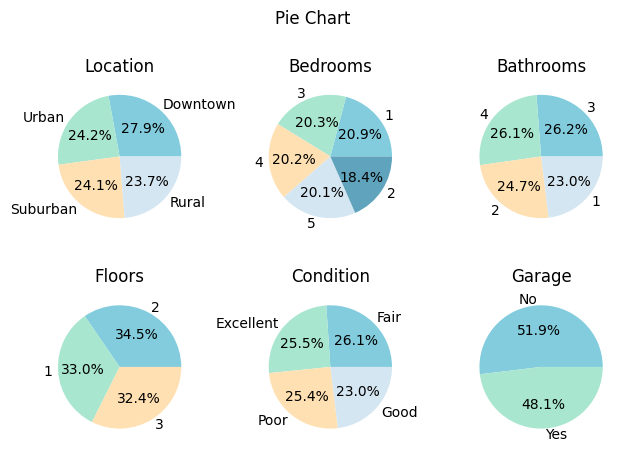

In [15]:
cols = ['Location','Bedrooms','Bathrooms','Floors','Condition','Garage']
pie_colors = ["#82ccdd", "#a8e6cf", "#ffe0b2", "#d4e6f1", "#60a3bc"]

for col in cols:
  plt.subplot(2,3,cols.index(col)+1)
  plt.pie(df[col].value_counts(),labels=df[col].value_counts().index,autopct='%1.1f%%',colors=pie_colors)
  plt.title(col)
  plt.suptitle('Pie Chart')
plt.tight_layout()
plt.show()

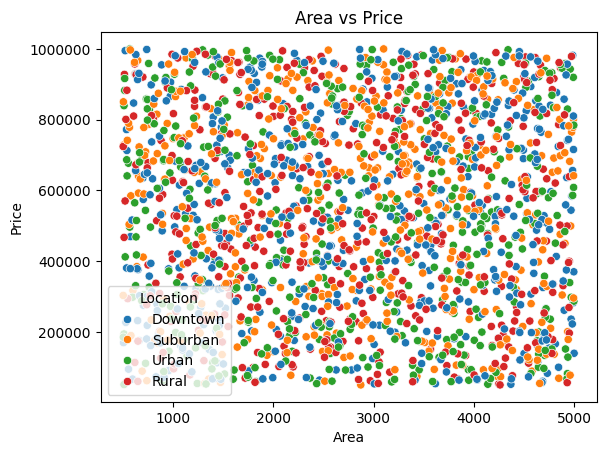

In [16]:
sns.scatterplot(x=df['Area'],y=df['Price'],hue=df['Location'])
plt.gca().ticklabel_format(style='plain')
plt.title('Area vs Price')
plt.show()

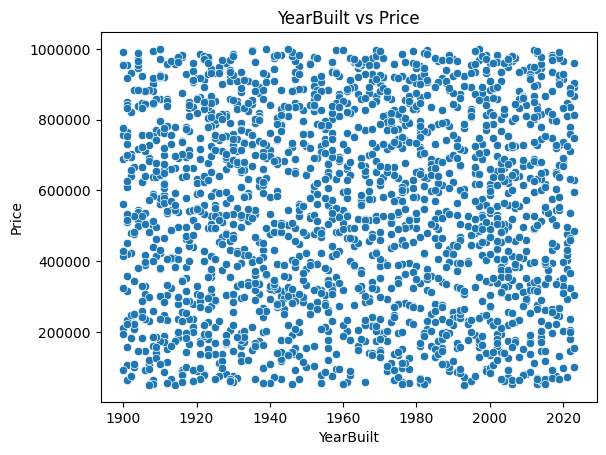

In [17]:
sns.scatterplot(x=df['YearBuilt'],y=df['Price'])
plt.gca().ticklabel_format(style='plain')
plt.title('YearBuilt vs Price')
plt.show()

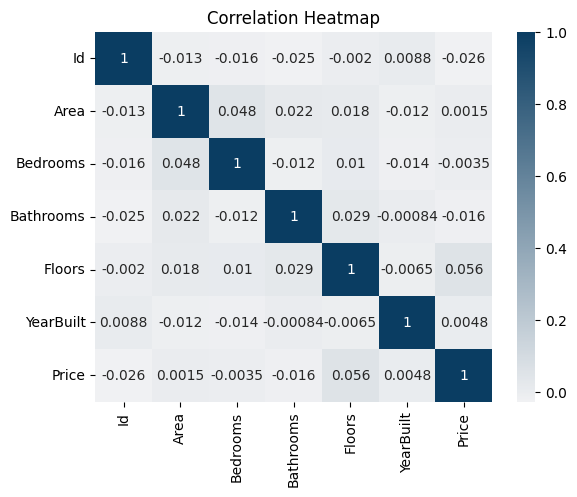

In [18]:
heatmap_cmap = sns.light_palette("#0a3d62", as_cmap=True)

sns.heatmap(df.corr(numeric_only=True),annot=True,cmap=heatmap_cmap)
plt.title('Correlation Heatmap')
plt.show()

# Data Preprocessing

In [19]:
df.drop(columns=['Id'],inplace=True)
location_rank = {
    'Rural': 0,
    'Suburban': 1,
    'Urban': 2,
    'Downtown': 3
}
df['Location'] = df['Location'].map(location_rank)

condition = {
    'Poor': 0,
    'Fair': 1,
    'Good': 3,
    'Excellent': 4
}
df['Condition'] = df['Condition'].map(condition)

df['Garage'] = df['Garage'].map({'Yes': 1, 'No': 0})

df['House_Age'] = 2026 - df['YearBuilt']
df.drop(columns=['YearBuilt'],inplace=True)

In [20]:
df = df.astype({'Location':'int','Condition':'int','Garage':'int'})

In [21]:
from sklearn.preprocessing import StandardScaler
col = ['Area','House_Age']
scaler = StandardScaler()
df[col] = scaler.fit_transform(df[col]) 

In [22]:
X = df.drop(columns=['Price'])
y = df['Price']

# Model Training

In [23]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ -433.99, 57.99,-9973.71,...,-4383.3 , 2674.32,-4055.81]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Area','Bedrooms','Bathrooms',...,'Condition','Garage','House_Age']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.266e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


In [25]:
y_pred = model.predict(X_test)

# Model Evaluation

In [26]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print('R2 Score:',r2)
print('MAE:',mae)
print('MSE:',mse)

R2 Score: -0.014186731349100201
MAE: 244703.85279302121
MSE: 78902539599.3859
